### Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

### Load Data

In [3]:
df = pd.read_csv(
    "/content/customer_features_v3.csv"
)
print(df.shape)
df.head()

(94760, 24)


,customer_unique_id,customer_state,frequency,recency_days,monetary_value,avg_order_value,total_items_purchased,avg_freight_cost,total_orders,delivered_order_rate,...,unique_products,unique_categories,unique_sellers,avg_review_score,good_review_rate,bad_review_rate,avg_installments,total_payment_value,weekend_purchase_ratio,monthly_purchase_frequency
0,861eff4711a542e4b93843c6dd7febb0,SP,1,519,124.99,124.99,1,21.88,1,1.0,...,1,1,1,4.0,1.0,0.0,2.0,146.87,0.0,0.041667
1,290c77bc529b7ac935b93aa66c333dc3,SP,1,277,289.00,289.00,1,46.48,1,1.0,...,1,1,1,5.0,1.0,0.0,8.0,335.48,0.0,0.041667
2,060e732b5b29e8181a18229c7b0b2b5e,SP,1,151,139.94,139.94,1,17.79,1,1.0,...,1,1,1,5.0,1.0,0.0,7.0,157.73,1.0,0.041667
3,259dac757896d24d7702b9acbbff3f3c,SP,1,218,149.94,149.94,1,23.36,1,1.0,...,1,1,1,5.0,1.0,0.0,1.0,173.30,0.0,0.041667
4,345ecd01c38d18a9036ed96c73b8d066,SP,1,80,230.00,230.00,1,22.25,1,1.0,...,1,1,1,5.0,1.0,0.0,8.0,252.25,1.0,0.041667


### Drop Unnecessary Columns

In [4]:
drop_cols = [
    "customer_unique_id",
    "customer_state",
    "total_orders",
    "monthly_purchase_frequency"
]

df = df.drop(
    columns=drop_cols,
    errors="ignore"
)

print(df.shape)

(94760, 20)


### Handle Missing Values

In [5]:
imputer = SimpleImputer(
    strategy="median"
)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df_imputed.isnull().sum().sum()

np.int64(0)

### Apply Log Transformation to Skewed Columns

In [6]:
skew_cols = [
    "monetary_value",
    "avg_order_value",
    "total_payment_value",
    "avg_freight_cost"
]

for col in skew_cols:
    df_imputed[col] = np.log1p(
        df_imputed[col]
    )

### Verify Log Transformation

In [7]:
df_imputed[skew_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
monetary_value,94760.0,4.488447,0.925462,0.615186,3.889726,4.509760,5.049856,9.506065
avg_order_value,94760.0,4.465880,0.915100,0.615186,3.854394,4.477337,5.016617,9.506065
total_payment_value,94760.0,4.732285,0.810625,2.359910,4.160444,4.691348,5.217012,9.522599
avg_freight_cost,94760.0,2.910452,0.503164,0.000000,2.665143,2.856470,3.100993,6.017814


### Standardize Data

In [8]:
scaler = StandardScaler()

scaled = scaler.fit_transform(
    df_imputed
)

X = pd.DataFrame(
    scaled,
    columns=df_imputed.columns
)

X.head()

,frequency,recency_days,monetary_value,avg_order_value,total_items_purchased,avg_freight_cost,delivered_order_rate,cancelled_order_rate,avg_delivery_time_days,avg_delay_days,late_delivery_rate,unique_products,unique_categories,unique_sellers,avg_review_score,good_review_rate,bad_review_rate,avg_installments,total_payment_value,weekend_purchase_ratio
0,-0.164203,1.515371,0.375767,0.404681,-0.291646,0.436861,0.151068,-0.071069,-0.429117,0.089163,-0.266467,-0.217795,-0.055231,-0.175891,-0.077127,0.541324,-0.409469,-0.336699,0.325737,-0.549084
1,-0.164203,-0.064646,1.276595,1.315710,-0.291646,1.887779,0.151068,-0.071069,0.424629,0.390268,-0.266467,-0.217795,-0.055231,-0.175891,0.676898,0.541324,-0.409469,1.906940,1.340027,-0.549084
2,-0.164203,-0.887300,0.496930,0.527217,-0.291646,0.045458,0.151068,-0.071069,1.491812,1.293585,3.799359,-0.217795,-0.055231,-0.175891,0.676898,0.541324,-0.409469,1.533000,0.413165,1.840294
3,-0.164203,-0.449857,0.571000,0.602125,-0.291646,0.561432,0.151068,-0.071069,0.211192,-0.111574,-0.266467,-0.217795,-0.055231,-0.175891,0.676898,0.541324,-0.409469,-0.710639,0.528599,-0.549084
4,-0.164203,-1.350858,1.030810,1.067142,-0.291646,0.468743,0.151068,-0.071069,-0.108962,0.591005,-0.266467,-0.217795,-0.055231,-0.175891,0.676898,0.541324,-0.409469,1.906940,0.989479,1.840294


### Verify Standardization

In [9]:
X.describe().T[
    ["mean","std"]
].head()

,mean,std
frequency,2.327485e-16,1.000005
recency_days,1.377070e-16,1.000005
monetary_value,1.184738e-16,1.000005
avg_order_value,2.508945e-16,1.000005
total_items_purchased,-1.175740e-16,1.000005


### Perform PCA - Explained Variance Calculation

In [10]:
pca = PCA()

pca.fit(X)

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

### Visualize PCA Explained Variance

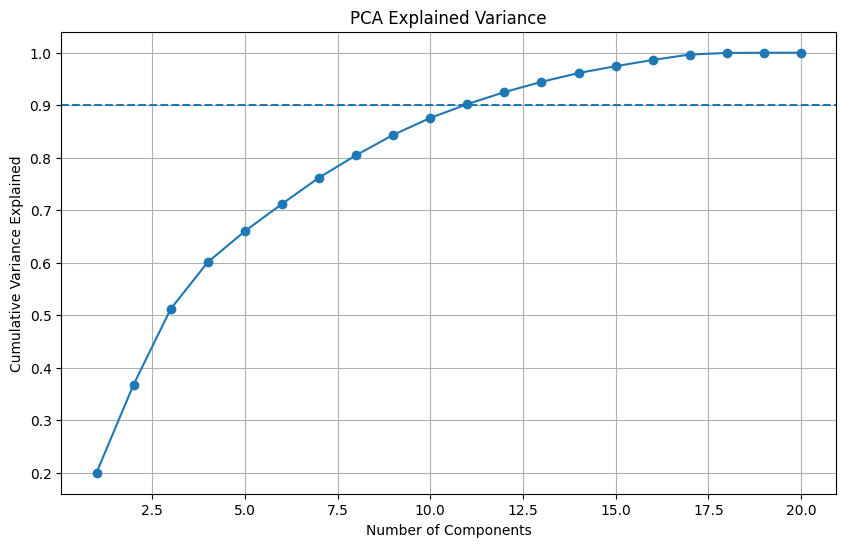

In [11]:
plt.figure(figsize=(10,6))

plt.plot(
    range(
        1,
        len(explained_variance)+1
    ),
    explained_variance,
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Cumulative Variance Explained"
)

plt.title(
    "PCA Explained Variance"
)

plt.grid()

plt.show()

### Determine Number of Components for 90% Variance

In [12]:
n_components_90 = (
    np.argmax(
        explained_variance >= 0.90
    )
    + 1
)

print(
    "Components for 90% variance:",
    n_components_90
)

Components for 90% variance: 11


### Apply PCA with Selected Components

In [13]:
pca = PCA(
    n_components=n_components_90,
    random_state=42
)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(94760, 11)


### K-Means Clustering: Elbow Method (Inertia)

In [14]:
inertia = []

K = range(2,11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    inertia.append(
        kmeans.inertia_
    )

### Visualize Elbow Method

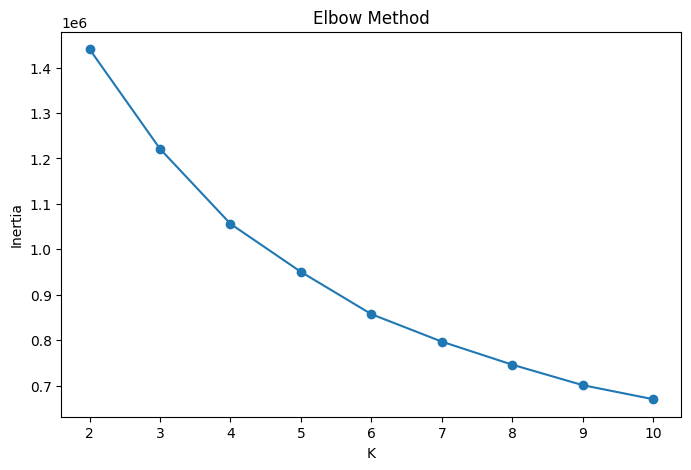

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("K")

plt.ylabel("Inertia")

plt.title(
    "Elbow Method"
)

plt.show()

### K-Means Clustering: Silhouette Analysis

In [16]:
sil_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_pca
    )

    score = silhouette_score(
        X_pca,
        labels
    )

    sil_scores.append(score)

    print(
        f"K={k}, Silhouette={score:.4f}"
    )

K=2, Silhouette=0.3921
K=3, Silhouette=0.3934
K=4, Silhouette=0.1951
K=5, Silhouette=0.2051
K=6, Silhouette=0.2218
K=7, Silhouette=0.2291
K=8, Silhouette=0.2150
K=9, Silhouette=0.1952
K=10, Silhouette=0.1969


### Visualize Silhouette Scores

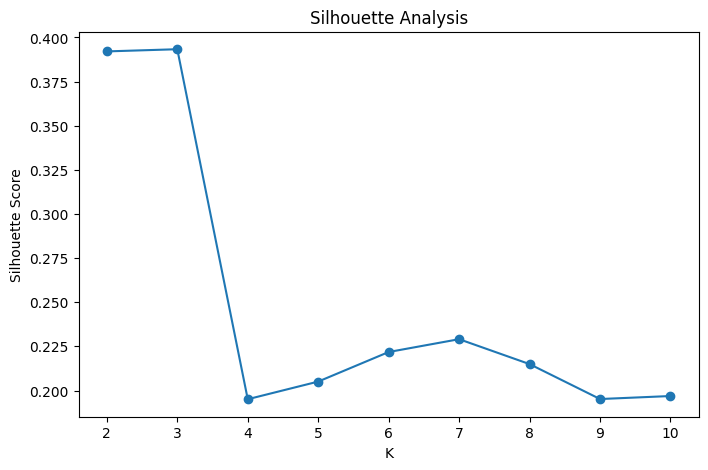

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    sil_scores,
    marker="o"
)

plt.xlabel("K")

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Silhouette Analysis"
)

plt.show()

### Prepare Data for 2D Visualization

In [18]:
pca_2d = PCA(
    n_components=2,
    random_state=42
)

X_2d = pca_2d.fit_transform(X)

### Perform K-Means Clustering (k=5)

In [19]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

### Visualize Customer Clusters in PCA Space

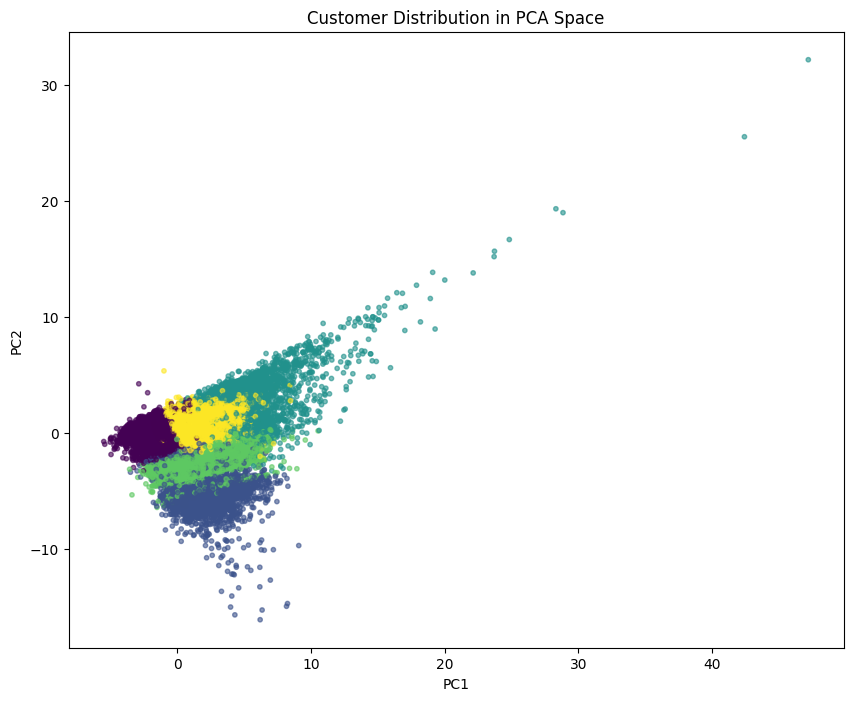

In [20]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=labels,
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Customer Distribution in PCA Space"
)

plt.show()